In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
df = pd.read_excel("RunningTimeRecord.xlsx", sheet_name="Testing 1", skiprows=3)

df.head()

,n,Computational Time (sec),Overall Time (sec),Computational Time (sec).1,Overall Time (sec).1,Speedup
0,10000000,4.221819,NaN,0.664019,NaN,6.357979
1,11000000,4.74567,NaN,0.760851,NaN,6.237318
2,12000000,5.463295,NaN,0.847935,NaN,6.443059
3,13000000,6.068673,NaN,0.93635,NaN,6.481201
4,14000000,6.786482,NaN,1.072575,NaN,6.32728


In [16]:
df2 = df.iloc[0:31, [0,1,3,5]]

df2

,n,Computational Time (sec),Computational Time (sec).1,Speedup
0,10000000,4.221819,0.664019,6.357979
1,11000000,4.74567,0.760851,6.237318
2,12000000,5.463295,0.847935,6.443059
3,13000000,6.068673,0.93635,6.481201
4,14000000,6.786482,1.072575,6.32728
5,15000000,7.513092,1.16066,6.47312
6,16000000,8.243417,1.268275,6.499708
7,17000000,9.038981,1.379663,6.551586
8,18000000,11.076497,1.566074,7.07278
9,19000000,11.668154,1.63604,7.131949


In [17]:
df2.rename(columns={"Computational Time (sec)": "serial_comp_time",
                          "Computational Time (sec).1": "parallel_comp_time"},
                          inplace=True)

df2

,n,serial_comp_time,parallel_comp_time,Speedup
0,10000000,4.221819,0.664019,6.357979
1,11000000,4.74567,0.760851,6.237318
2,12000000,5.463295,0.847935,6.443059
3,13000000,6.068673,0.93635,6.481201
4,14000000,6.786482,1.072575,6.32728
5,15000000,7.513092,1.16066,6.47312
6,16000000,8.243417,1.268275,6.499708
7,17000000,9.038981,1.379663,6.551586
8,18000000,11.076497,1.566074,7.07278
9,19000000,11.668154,1.63604,7.131949


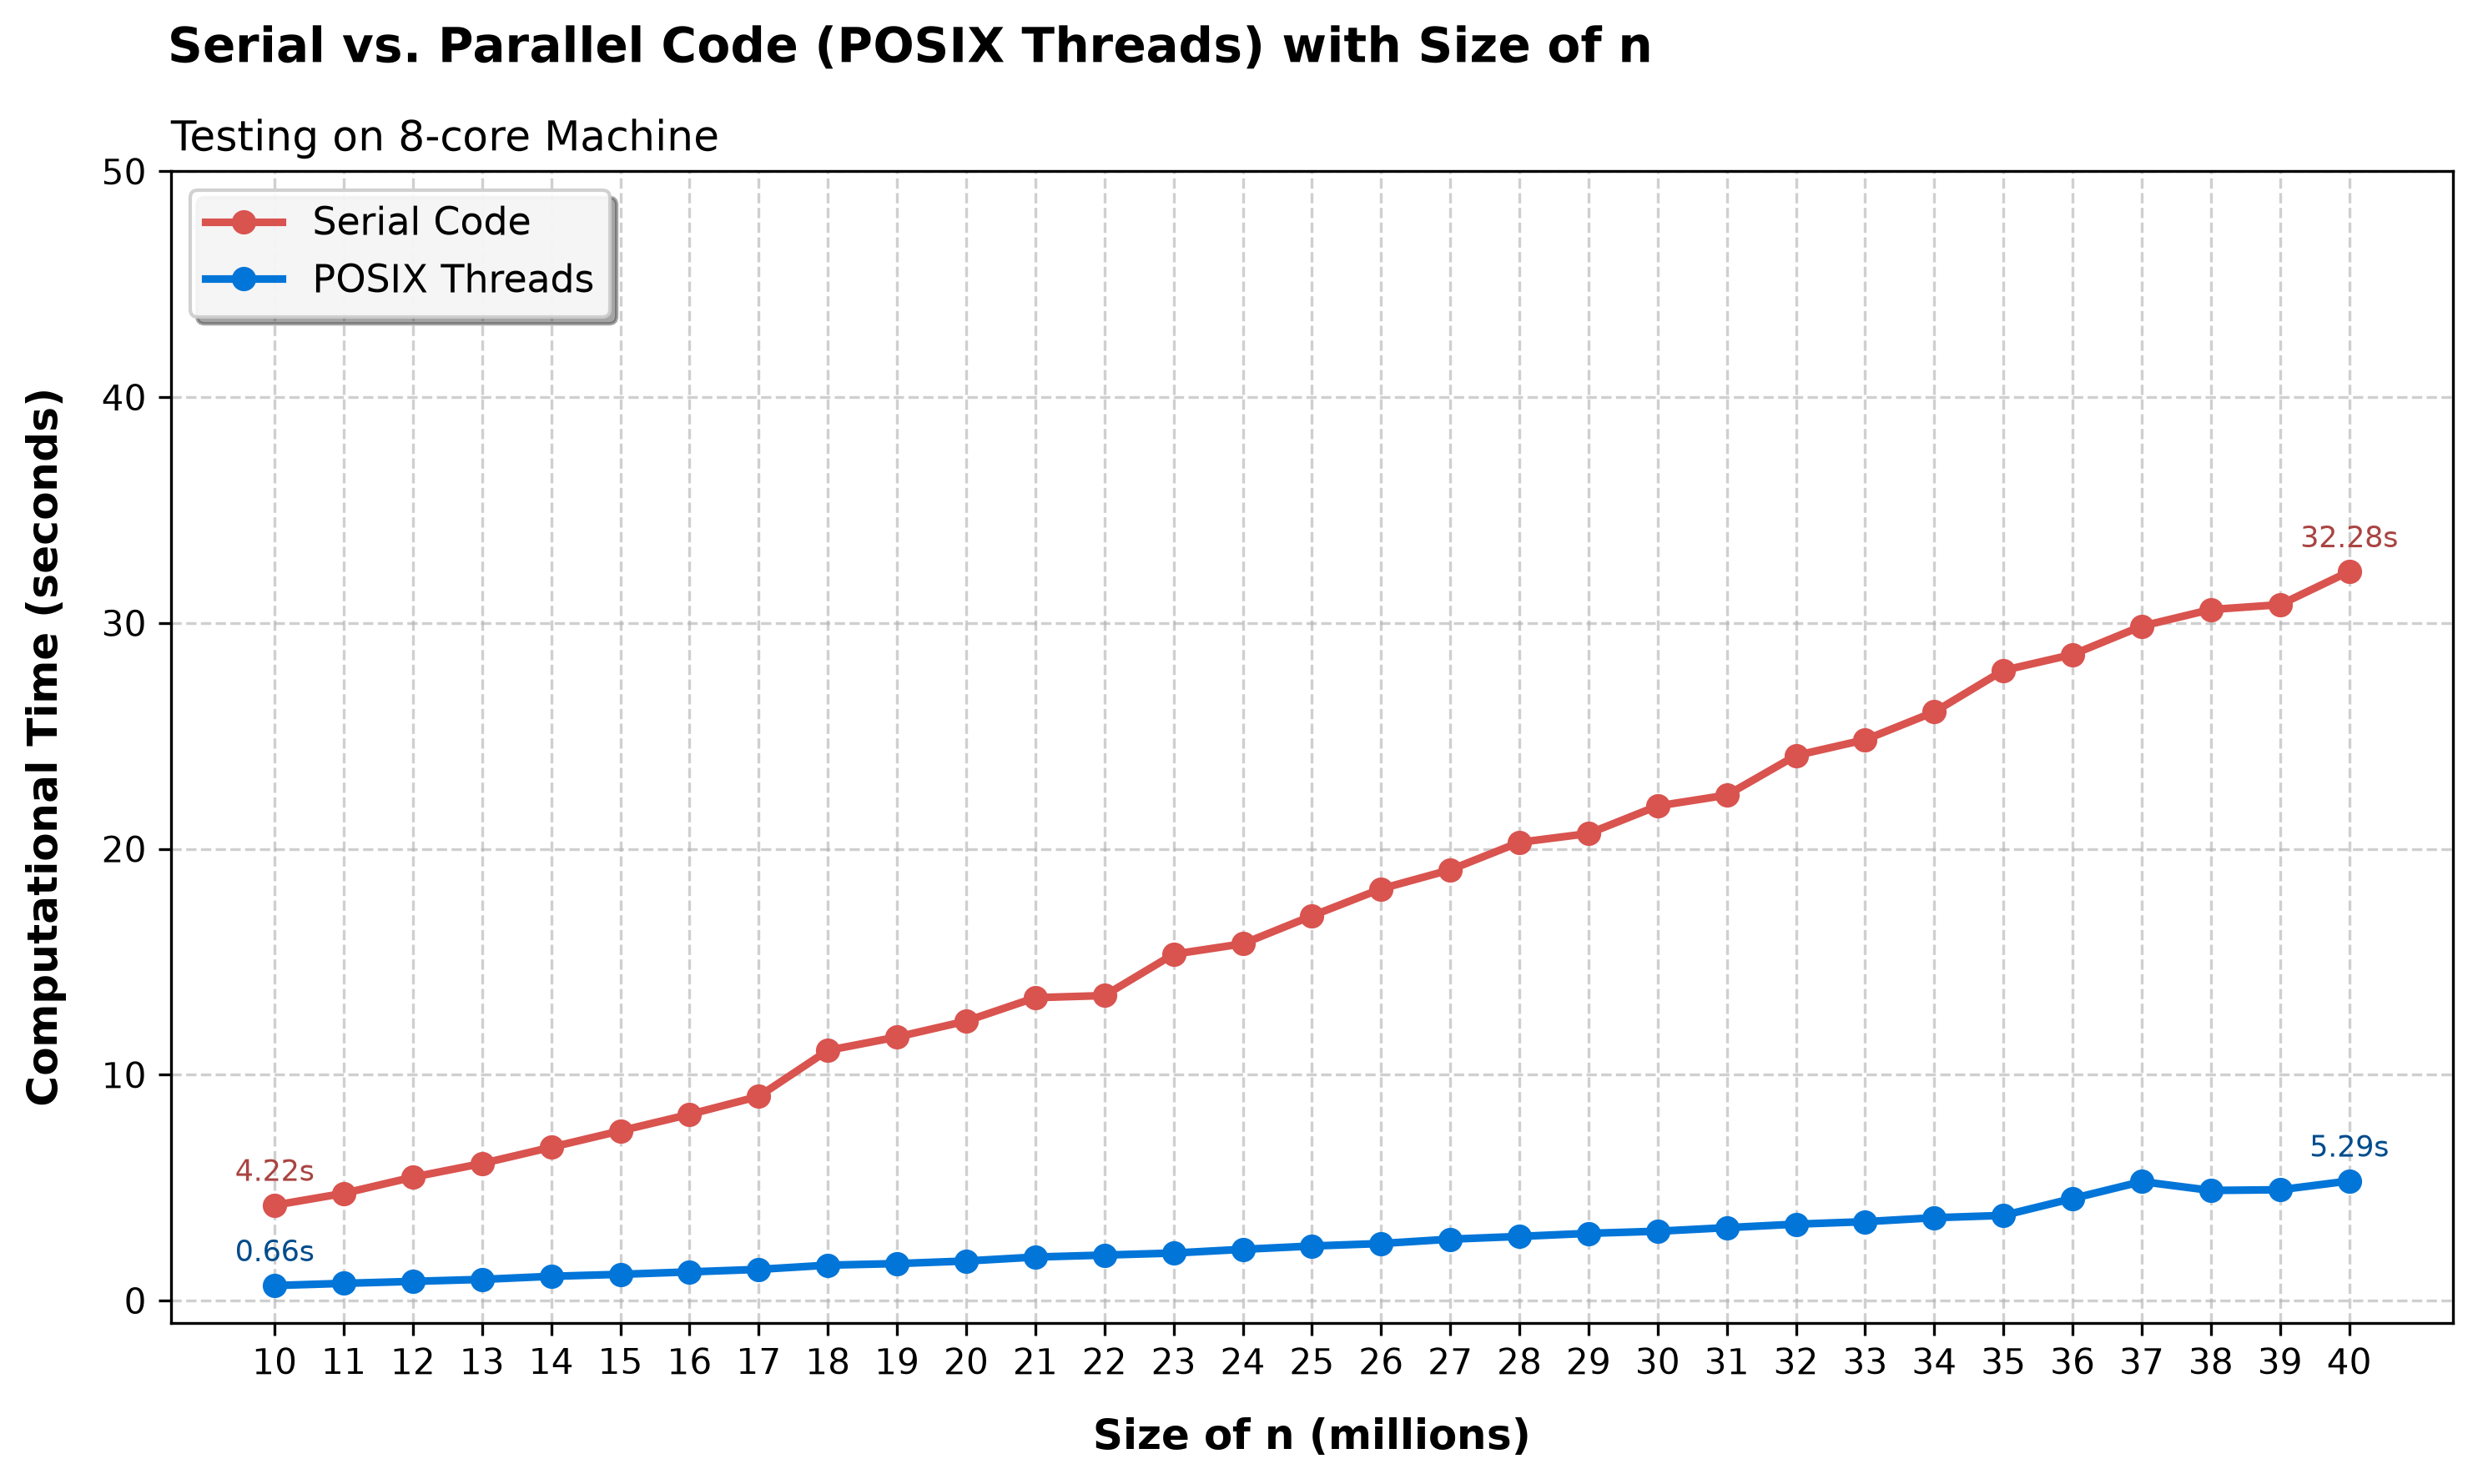

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 6), dpi=300)

plt.plot(df2.n, df2.serial_comp_time, marker='o', markersize=6, linewidth=2.2, color='#D9534F', label='Serial Code')
plt.plot(df2.n, df2.parallel_comp_time, marker='o', markersize=6, linewidth=2.2, color='#0275D8', label='POSIX Threads')

plt.suptitle("Serial vs. Parallel Code (POSIX Threads) with Size of n", fontsize=14, fontweight='bold', x=0.072, ha='left')
plt.title("Testing on 8-core Machine", fontsize=12, loc='left')
plt.xlabel("Size of n (millions)", fontsize=12, fontweight='semibold', labelpad=10)
plt.ylabel("Computational Time (seconds)", fontsize=12, fontweight='semibold', labelpad=10)

plt.xticks(df2.n, [f"{x / 1_000_000:g}" for x in df2.n], fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

plt.ylim(-1, 50)

plt.legend(fontsize=11, loc='upper left', frameon=True, framealpha=0.9, shadow=True)

plt.annotate(f"{df2.serial_comp_time[0]:.2f}s",
             (df2.n[0], df2.serial_comp_time[0]),
             textcoords='offset points',
             xytext=(0, 7),
             ha='center',
             fontsize=8.5, color='#A94442')

plt.annotate(f"{df2.serial_comp_time[len(df2.n)-1]:.2f}s",
             (df2.n[len(df2.n)-1], df2.serial_comp_time[len(df2.n)-1]),
             textcoords='offset points',
             xytext=(0, 7),
             ha='center',
             fontsize=8.5, color='#A94442')

plt.annotate(f"{df2.parallel_comp_time[0]:.2f}s",
             (df2.n[0], df2.parallel_comp_time[0]),
             textcoords='offset points',
             xytext=(0, 7),
             ha='center',
             fontsize=8.5, color='#014C8C')

plt.annotate(f"{df2.parallel_comp_time[len(df2.n)-1]:.2f}s",
             (df2.n[len(df2.n)-1], df2.parallel_comp_time[len(df2.n)-1]),
             textcoords='offset points',
             xytext=(0, 7),
             ha='center',
             fontsize=8.5, color='#014C8C')

plt.tight_layout()
plt.show()

# plt.savefig("task2_graph1_8.png", dpi=300)

In [24]:
df3 = df.iloc[35:66, [0,1,3,5]].copy()

df3.rename(columns={"Computational Time (sec)": "serial_comp_time",
                          "Computational Time (sec).1": "parallel_comp_time"},
                          inplace=True)

df3.reset_index(drop=True, inplace=True)

df3

,n,serial_comp_time,parallel_comp_time,Speedup
0,10000000,3.07422,0.199615,15.400746
1,11000000,4.093555,0.208622,19.621876
2,12000000,4.904312,0.230629,21.264941
3,13000000,5.495484,0.268316,20.481388
4,14000000,6.132882,0.29424,20.843128
5,15000000,6.798875,0.319859,21.25585
6,16000000,7.449279,0.374307,19.901522
7,17000000,7.97893,0.412031,19.364878
8,18000000,8.72128,0.392722,22.207261
9,19000000,9.375312,0.411162,22.80199


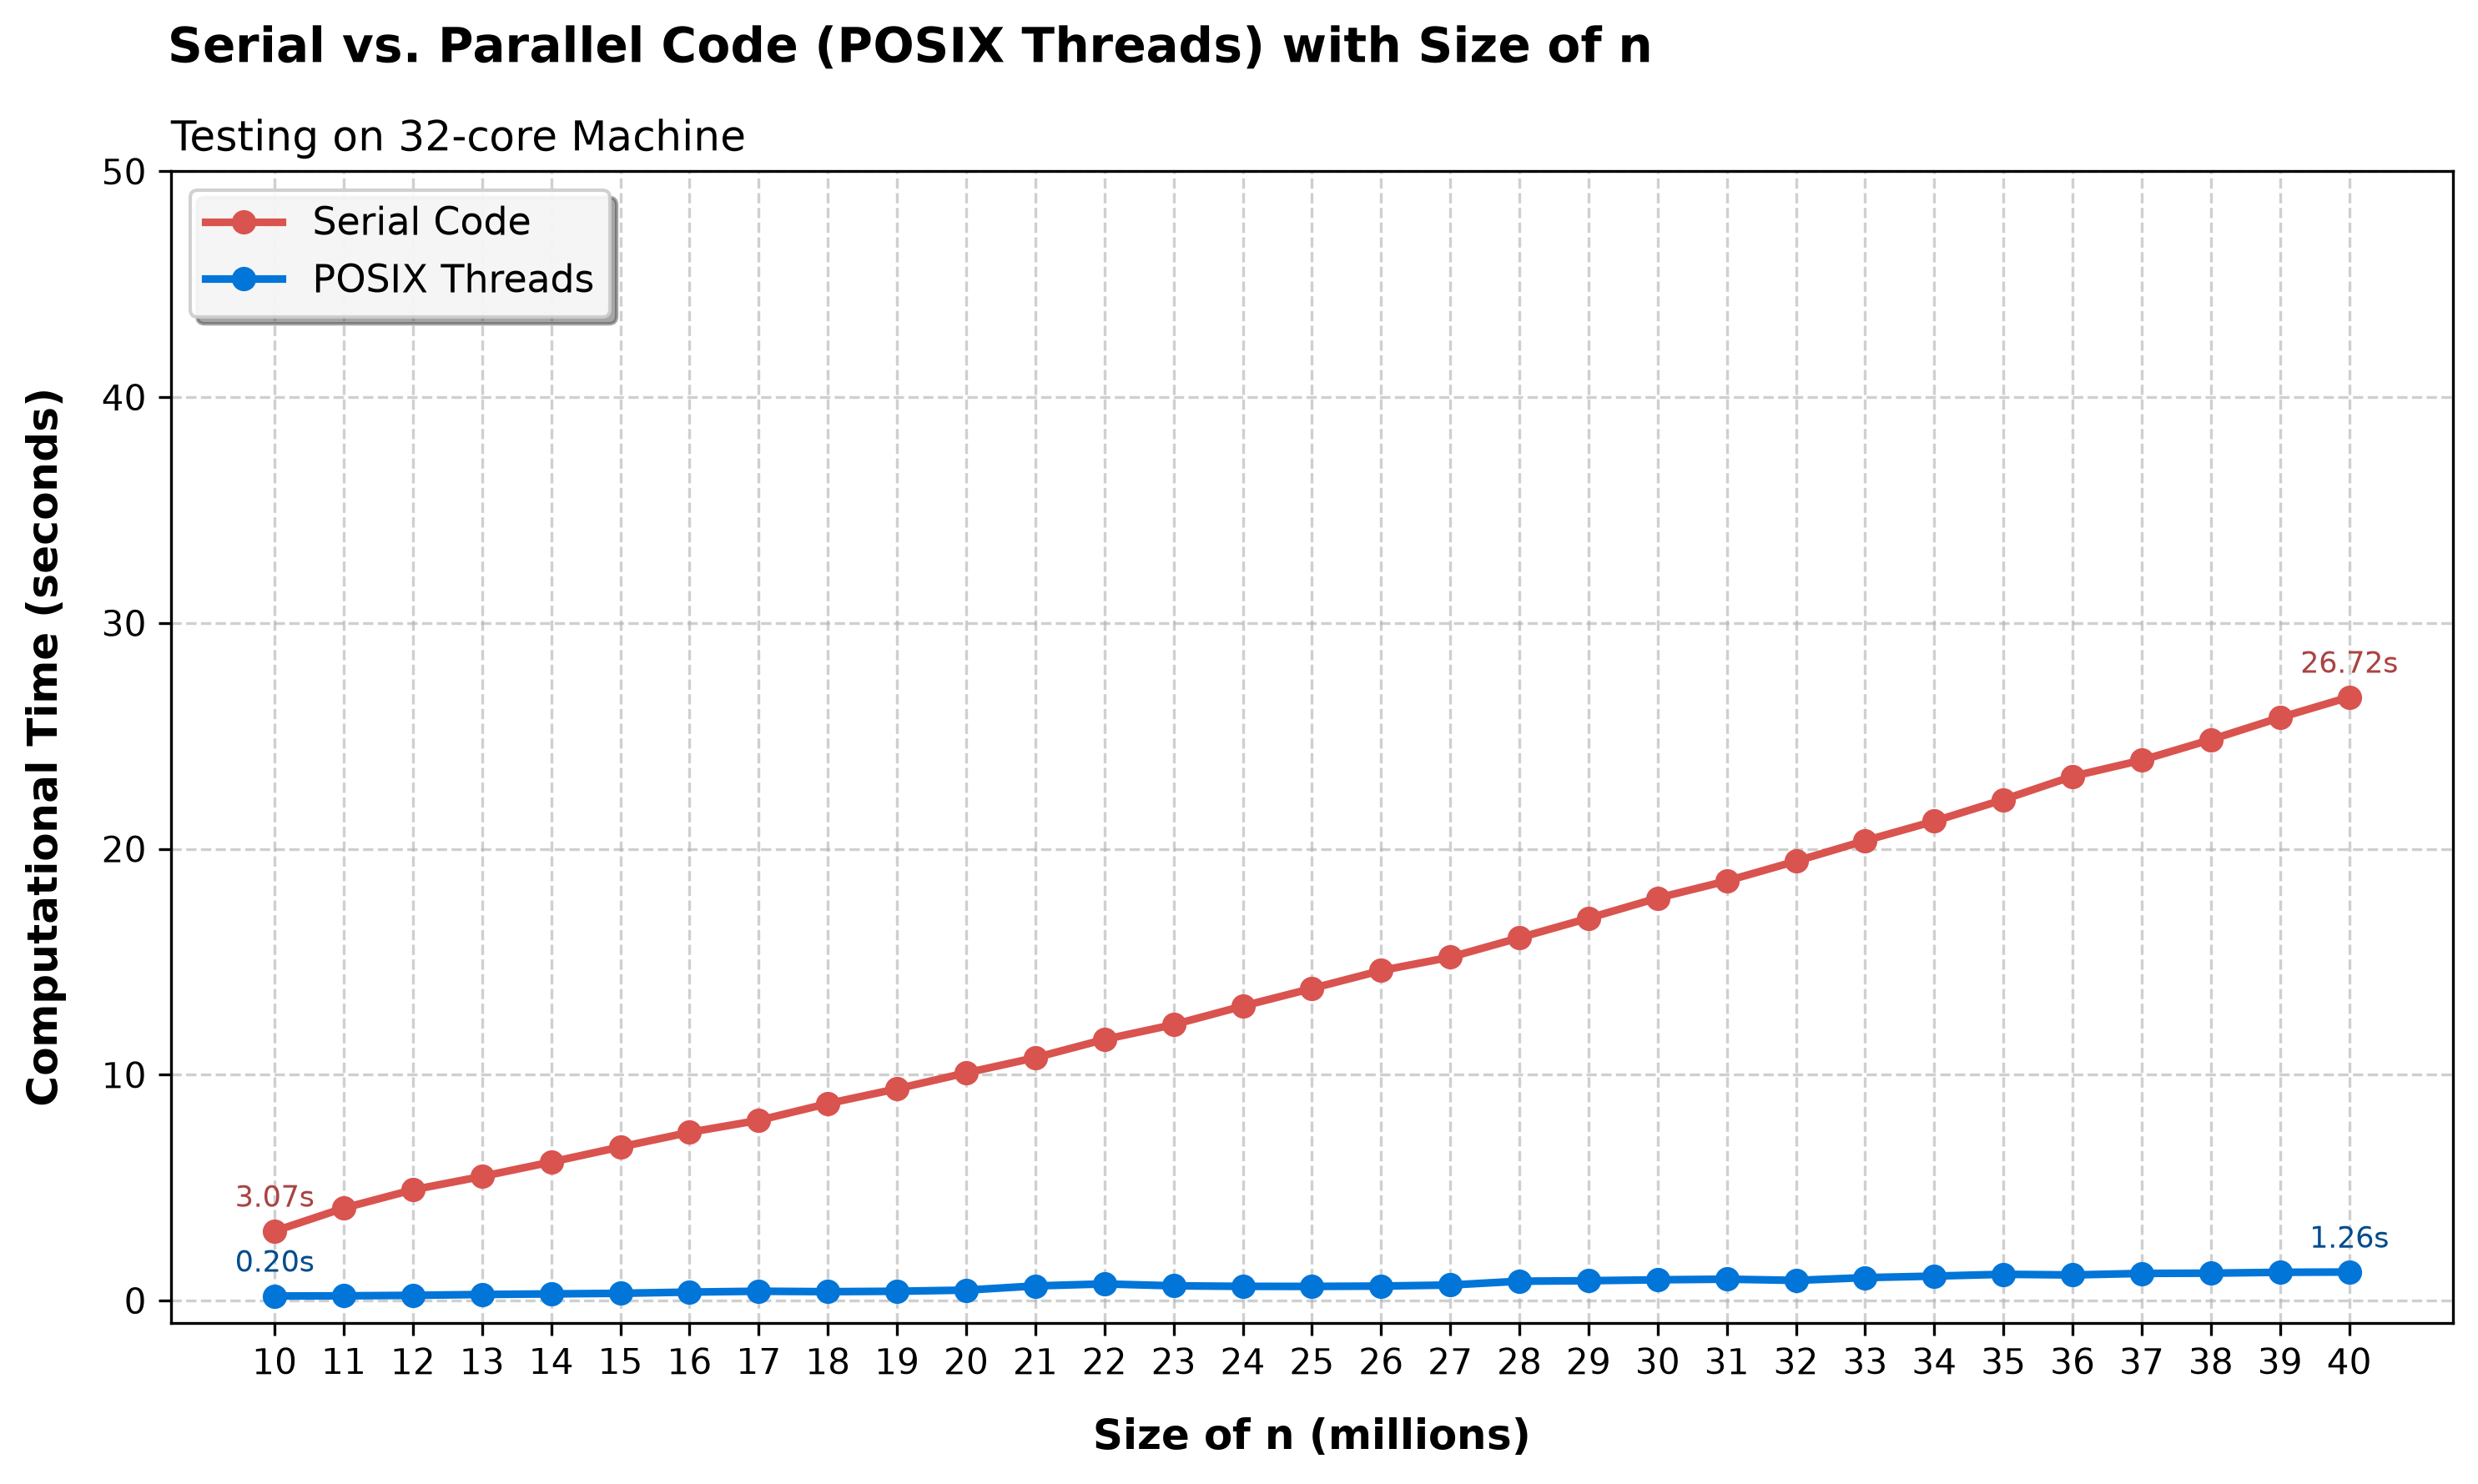

In [25]:
plt.figure(figsize=(10, 6), dpi=300)

plt.plot(df3.n, df3.serial_comp_time, marker='o', markersize=6, linewidth=2.2, color='#D9534F', label='Serial Code')
plt.plot(df3.n, df3.parallel_comp_time, marker='o', markersize=6, linewidth=2.2, color='#0275D8', label='POSIX Threads')

plt.suptitle("Serial vs. Parallel Code (POSIX Threads) with Size of n", fontsize=14, fontweight='bold', x=0.072, ha='left')
plt.title("Testing on 32-core Machine", fontsize=12, loc='left')
plt.xlabel("Size of n (millions)", fontsize=12, fontweight='semibold', labelpad=10)
plt.ylabel("Computational Time (seconds)", fontsize=12, fontweight='semibold', labelpad=10)

plt.xticks(df3.n, [f"{x / 1_000_000:g}" for x in df3.n], fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

plt.ylim(-1, 50)

plt.legend(fontsize=11, loc='upper left', frameon=True, framealpha=0.9, shadow=True)

plt.annotate(f"{df3.serial_comp_time[0]:.2f}s",
             (df3.n[0], df3.serial_comp_time[0]),
             textcoords='offset points',
             xytext=(0, 7),
             ha='center',
             fontsize=8.5, color='#A94442')

plt.annotate(f"{df3.serial_comp_time[len(df3.n)-1]:.2f}s",
             (df3.n[len(df3.n)-1], df3.serial_comp_time[len(df3.n)-1]),
             textcoords='offset points',
             xytext=(0, 7),
             ha='center',
             fontsize=8.5, color='#A94442')

plt.annotate(f"{df3.parallel_comp_time[0]:.2f}s",
             (df3.n[0], df3.parallel_comp_time[0]),
             textcoords='offset points',
             xytext=(0, 7),
             ha='center',
             fontsize=8.5, color='#014C8C')

plt.annotate(f"{df3.parallel_comp_time[len(df3.n)-1]:.2f}s",
             (df3.n[len(df3.n)-1], df3.parallel_comp_time[len(df3.n)-1]),
             textcoords='offset points',
             xytext=(0, 7),
             ha='center',
             fontsize=8.5, color='#014C8C')

plt.tight_layout()
plt.show()

# plt.savefig("task2_graph1_32.png", dpi=300)

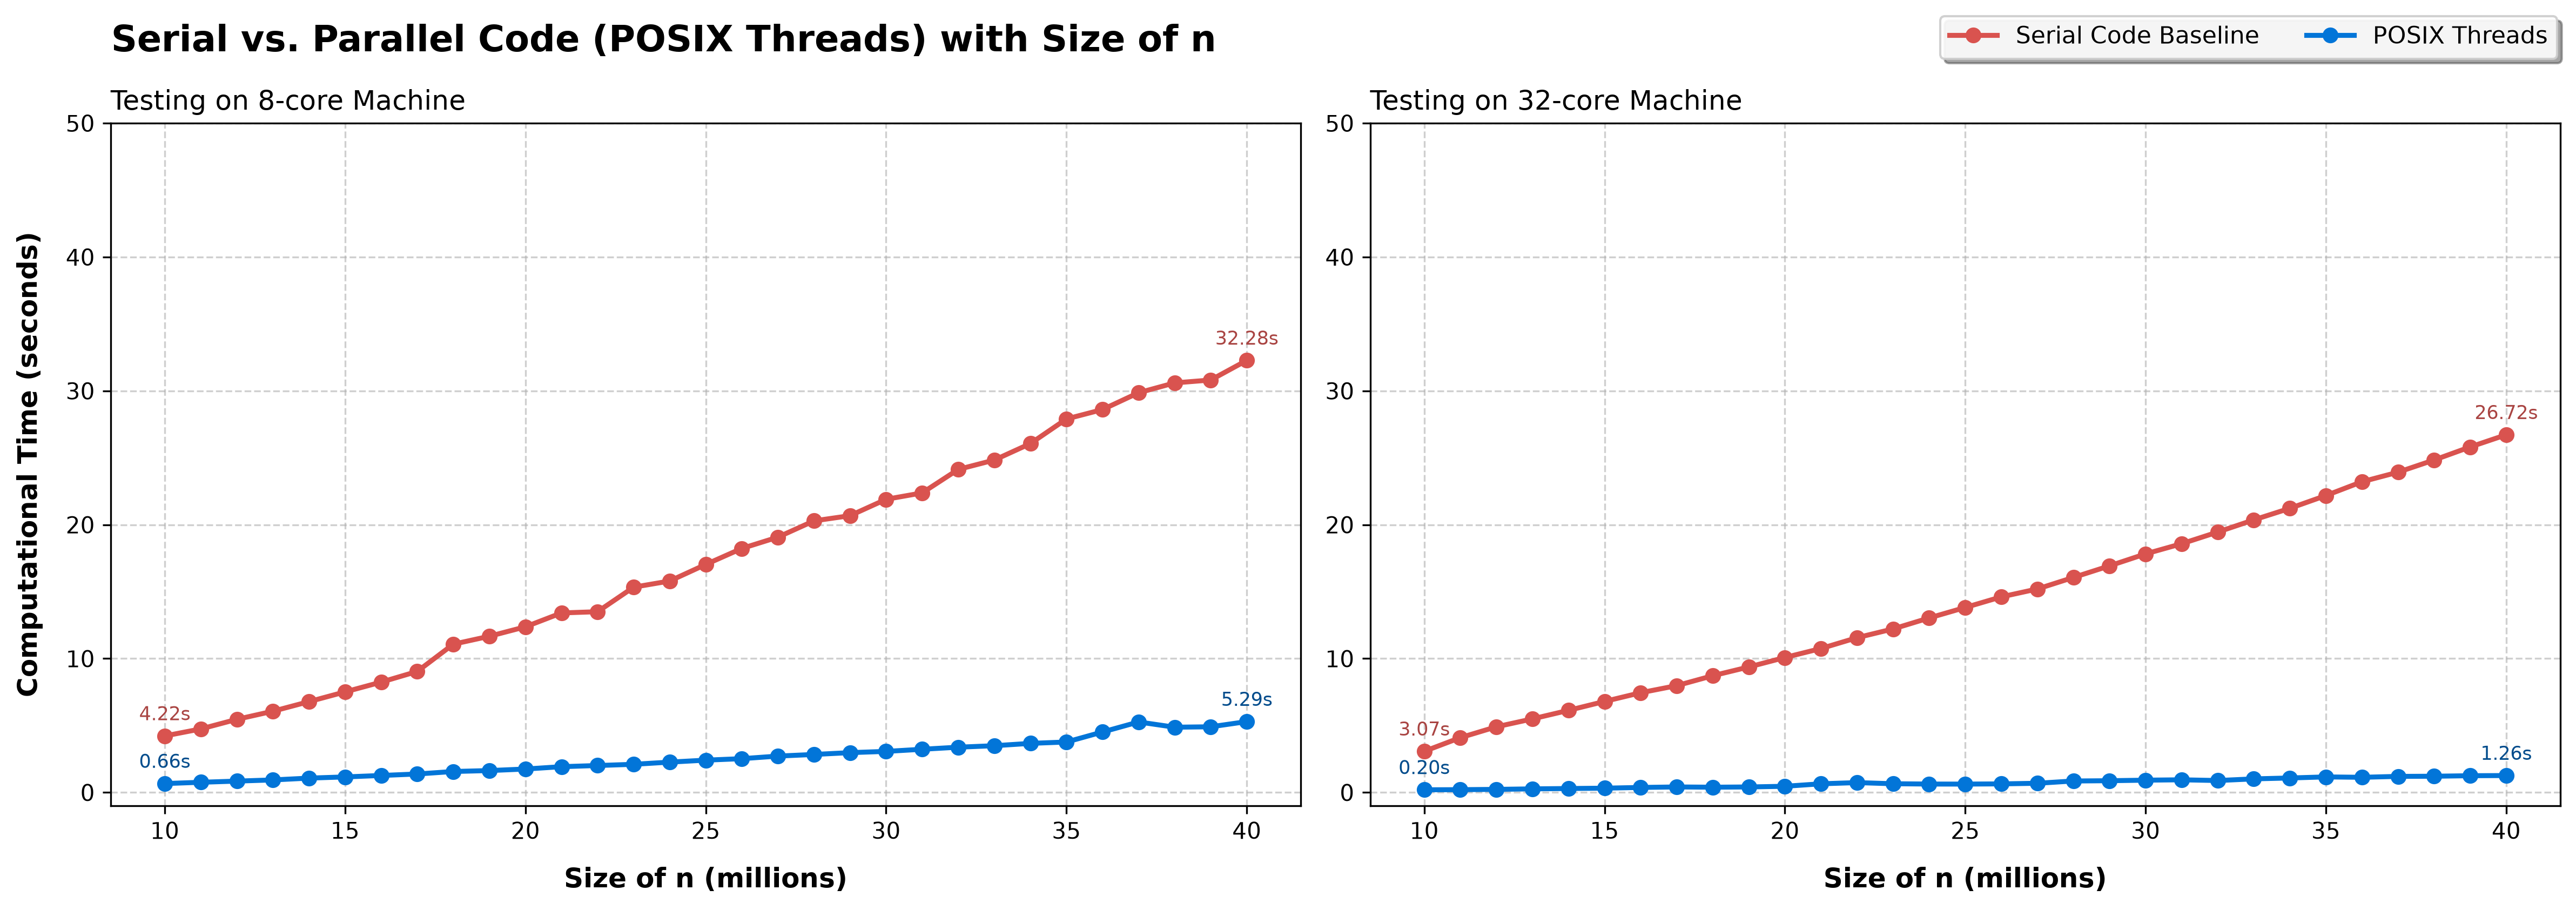

In [28]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)


# =========================
# 8-core graph
# =========================
ax = axes[0]

line1, = ax.plot(
    df2.n, df2.serial_comp_time,
    marker='o', markersize=6, linewidth=2.2,
    color='#D9534F', label='Serial Code'
)

line2, = ax.plot(
    df2.n, df2.parallel_comp_time,
    marker='o', markersize=6, linewidth=2.2,
    color='#0275D8', label='POSIX Threads'
)

ax.set_title(
    "Testing on 8-core Machine",
    fontsize=12,
    loc='left'
)

ax.set_xlabel(
    "Size of n (millions)",
    fontsize=12,
    fontweight='semibold',
    labelpad=10
)

ax.set_ylabel(
    "Computational Time (seconds)",
    fontsize=12,
    fontweight='semibold',
    labelpad=10
)

# X-axis: show ticks/grid every 5 million
ax.xaxis.set_major_locator(MultipleLocator(5_000_000))
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1_000_000:g}")
)

ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(-1, 50)


# Annotations
ax.annotate(
    f"{df2.serial_comp_time.iloc[0]:.2f}s",
    (df2.n.iloc[0], df2.serial_comp_time.iloc[0]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color='#A94442'
)

ax.annotate(
    f"{df2.serial_comp_time.iloc[-1]:.2f}s",
    (df2.n.iloc[-1], df2.serial_comp_time.iloc[-1]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color='#A94442'
)

ax.annotate(
    f"{df2.parallel_comp_time.iloc[0]:.2f}s",
    (df2.n.iloc[0], df2.parallel_comp_time.iloc[0]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color='#014C8C'
)

ax.annotate(
    f"{df2.parallel_comp_time.iloc[-1]:.2f}s",
    (df2.n.iloc[-1], df2.parallel_comp_time.iloc[-1]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color='#014C8C'
)


# =========================
# 32-core graph
# =========================
ax = axes[1]

ax.plot(
    df3.n, df3.serial_comp_time,
    marker='o', markersize=6, linewidth=2.2,
    color='#D9534F', label='Serial Code'
)

ax.plot(
    df3.n, df3.parallel_comp_time,
    marker='o', markersize=6, linewidth=2.2,
    color='#0275D8', label='POSIX Threads'
)

ax.set_title(
    "Testing on 32-core Machine",
    fontsize=12,
    loc='left'
)

ax.set_xlabel(
    "Size of n (millions)",
    fontsize=12,
    fontweight='semibold',
    labelpad=10
)

# X-axis: show ticks/grid every 5 million
ax.xaxis.set_major_locator(MultipleLocator(5_000_000))
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1_000_000:g}")
)

ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(-1, 50)


# Annotations
ax.annotate(
    f"{df3.serial_comp_time.iloc[0]:.2f}s",
    (df3.n.iloc[0], df3.serial_comp_time.iloc[0]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color='#A94442'
)

ax.annotate(
    f"{df3.serial_comp_time.iloc[-1]:.2f}s",
    (df3.n.iloc[-1], df3.serial_comp_time.iloc[-1]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color='#A94442'
)

ax.annotate(
    f"{df3.parallel_comp_time.iloc[0]:.2f}s",
    (df3.n.iloc[0], df3.parallel_comp_time.iloc[0]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color='#014C8C'
)

ax.annotate(
    f"{df3.parallel_comp_time.iloc[-1]:.2f}s",
    (df3.n.iloc[-1], df3.parallel_comp_time.iloc[-1]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color='#014C8C'
)


# =========================
# Overall title
# =========================
fig.suptitle(
    "Serial vs. Parallel Code (POSIX Threads) with Size of n",
    fontsize=16,
    fontweight='bold',
    x=0.046,
    y=0.92,
    ha='left'
)


# =========================
# Overall legend
# =========================
fig.legend(
    handles=[line1, line2],
    labels=['Serial Code Baseline', 'POSIX Threads'],
    loc='upper right',
    bbox_to_anchor=(0.994, 0.94),
    ncol=2,
    fontsize=10.5,
    frameon=True,
    framealpha=0.9,
    shadow=True
)


# =========================
# Layout & save
# =========================
plt.tight_layout(rect=[0, 0, 1, 0.94])

plt.savefig(
    "task2_graph1.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()